In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ace_tools

In [3]:
import os
import json
import pandas as pd
from difflib import SequenceMatcher
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [4]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN"

In [5]:
spacy_ref = {
    "REF": f"{base_path}/DARIEN/REF/DARIEN_Le-voleur_REF.txt_spacy-lg-3.7.5.json",
    "TESSERACT": f"{base_path}/DARIEN/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_spacy-lg-3.7.5.json",
    "KRAKEN": f"{base_path}/DARIEN/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_spacy-lg-3.7.5.json"
}

In [6]:
model_dirs = {
    "initial": f"{base_path}/resultats_complet_initial",
    "enrichi": f"{base_path}/resultats_complet_enrichi",
    "quaero_fusioné": f"{base_path}/resultats_complet_enrichi_quaero_fusioné",
    "enrichi_80-20": f"{base_path}/resultats_complet_enrichi_80-20",
}

In [7]:
model_files = {
    modele: {
        "REF": f"{model_dirs[modele]}/DARIEN_Le-voleur_REF_tok2vec_{modele}.json",
        "TESSERACT": f"{model_dirs[modele]}/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_{modele}.json",
        "KRAKEN": f"{model_dirs[modele]}/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_{modele}.json"
    } for modele in model_dirs
}

In [8]:
def normaliser_label(label):
    if label.startswith("LOC"):
        return "LOC"
    if label.startswith("PER"):
        return "PER"
    if label.startswith("ORG"):
        return "ORG"
    if label.startswith("MISC"):
        return "MISC"
    return label.upper()

def charger_entites_fuzzy(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    entites = []
    for ent in data.values():
        texte = ent.get("text", "")
        label = ent.get("label", "").strip()
        debut, fin = ent.get("jalons", [None, None])
        if None not in (texte, label, debut, fin):
            entites.append({"text": texte, "label": label, "start": debut, "end": fin})
    return entites

def entites_equivalentes_fuzzy(ent1, ent2, tolerance=5):
    distance_debut = abs(ent1["start"] - ent2["start"])
    distance_fin = abs(ent1["end"] - ent2["end"])
    if distance_debut <= tolerance and distance_fin <= tolerance:
        sm = SequenceMatcher(None, ent1["text"].lower(), ent2["text"].lower())
        return sm.ratio() > 0.5
    return False

def analyser_longueurs_entites(spacy_ref, model_files, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    resultats = []

    for modele, fichiers in model_files.items():
        for ocr, chemin_model in fichiers.items():
            chemin_spacy = spacy_ref[ocr]
            try:
                entites_spacy = charger_entites_fuzzy(chemin_spacy)
                entites_modele = charger_entites_fuzzy(chemin_model)

                lignes = []

                for ent_ref in entites_spacy:
                    for ent_pred in entites_modele:
                        if entites_equivalentes_fuzzy(ent_ref, ent_pred):
                            lignes.append({
                                "OCR": ocr,
                                "Modèle": modele,
                                "Texte_spacy": ent_ref["text"],
                                "Longueur_spacy": len(ent_ref["text"]),
                                "Texte_modele": ent_pred["text"],
                                "Longueur_modele": len(ent_pred["text"]),
                                "Différence": len(ent_pred["text"]) - len(ent_ref["text"])
                            })
                            break

                df = pd.DataFrame(lignes)
                nom_fichier = f"comparaison_longueurs_{ocr}_{modele}.csv"
                df.to_csv(os.path.join(output_dir, nom_fichier), index=False, encoding="utf-8")
                resultats.append(df)

            except Exception as e:
                print(f"Erreur pour {modele}-{ocr}: {e}")

    return resultats

In [ ]:
output_dir = os.path.join(base_path, "longueurs_entites_comparaison")
os.makedirs(output_dir, exist_ok=True)

In [ ]:
resultats = analyser_longueurs_entites(spacy_ref, model_files, output_dir)

In [15]:
input_dir = os.path.join(base_path, "longueurs_entites_comparaison", "longueurs_entites_comparaison")
output_csv = os.path.join(input_dir, "resume_differences_longueurs.csv")

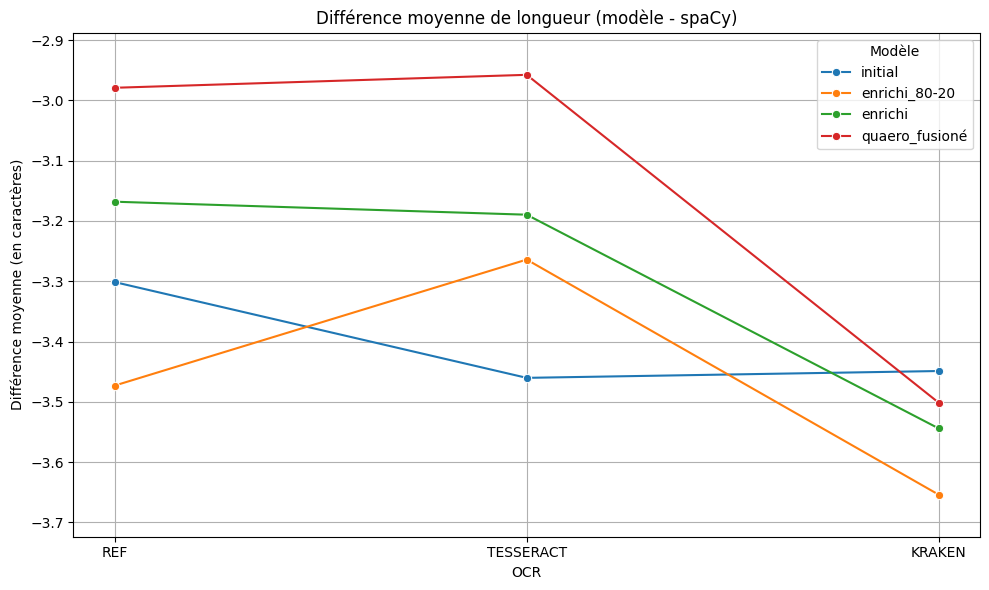

In [17]:
resumes = []
for nom_fichier in os.listdir(input_dir):
    if nom_fichier.startswith("comparaison_longueurs_") and nom_fichier.endswith(".csv"):
        try:
            chemin = os.path.join(input_dir, nom_fichier)
            df = pd.read_csv(chemin)

            if "Longueur_modele" not in df.columns or "Longueur_spacy" not in df.columns:
                continue

            df["Différence"] = df["Longueur_modele"] - df["Longueur_spacy"]
            ocr, modele = nom_fichier.replace("comparaison_longueurs_", "").replace(".csv", "").split("_", 1)

            resumes.append({
                "Modèle": modele,
                "OCR": ocr,
                "Moyenne différence": df[df["Différence"] != 0]["Différence"].mean(),  # on exclut les cas à 0
                "Écart-type": df["Différence"].std(),
                "Nb entités": len(df)
            })

        except Exception as e:
            print(f"Erreur lecture {nom_fichier} : {e}")

df_resume = pd.DataFrame(resumes)
df_resume.columns = df_resume.columns.str.strip()
df_resume["Modèle"] = df_resume["Modèle"].replace({"quaero_fusioné": "enrichi_quaero_fusioné"})
df_resume.to_csv(output_csv, index=False)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_resume, x="OCR", y="Moyenne différence", hue="Modèle", marker="o")
plt.xlabel("OCR")
plt.ylabel("Différence moyenne (en caractères)")
plt.title("Différence moyenne de longueur (modèle - spaCy)")

min_val = df_resume["Moyenne différence"].min()
max_val = df_resume["Moyenne différence"].max()
delta = (max_val - min_val) * 0.1
plt.ylim(min_val - delta, max_val + delta)

plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(input_dir, "resume_differences_longueurs.png"))
plt.show()